# Transfer Conformal Prediction Intervals

This tutorial evaluates the **conformal prediction transfer methods** available in `mlforecast`. We train a model on one domain (M4 Monthly **Macro** series) and then generate calibrated prediction intervals for a different domain (M4 Monthly **Finance** series) — without retraining the model.

## Why transfer?

Standard conformal prediction intervals are calibrated on the same distribution as training data. When you apply a pretrained model to **new, unseen series** from a potentially different domain, the source conformity scores may be miscalibrated for the target domain. Transfer conformal methods attempt to correct for this shift using different strategies:

| Method | Strategy | Needs CV on target? |
|---|---|---|
| `recalibrate` | Re-run cross-validation on target data | Yes |
| `scale_aligned` | Rescale source errors by target/source scale ratio (from *y* history) | No |
| `error_scaled` | Rescale source errors by target/source prediction error ratio | Yes |
| `weighted_conformal` | Reweight source errors via density-ratio estimation (covariate shift) | No |
| `scale_aligned_weighted` | Combine scale alignment with density-ratio weighting | No |

We evaluate each method's **empirical coverage** — the fraction of test observations that fall inside the predicted interval — and compare it to the nominal level.

## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mlforecast import MLForecast
from mlforecast.lag_transforms import ExpandingMean, RollingMean
from mlforecast.target_transforms import Differences
from mlforecast.utils import PredictionIntervals

## Load M4 Monthly Data

The M4 Monthly dataset contains 48,000 monthly time series across 6 categories. We use it to create a cross-domain transfer scenario:

- **Source domain**: `Macro` category — macroeconomic time series
- **Target domain**: `Finance` category — financial time series

The forecast horizon for M4 Monthly is **h = 18** months.

In [2]:
HORIZON = 18
DATA_DIR = '../../../data'

def read_and_melt(file):
    df = pd.read_csv(file)
    df.columns = ['unique_id'] + list(range(1, df.shape[1]))
    df = pd.melt(df, id_vars=['unique_id'], var_name='ds', value_name='y')
    df = df.dropna()
    df['ds'] = df['ds'].astype(int)
    return df

# Load train/test splits (M4 stores them separately)
m4_train = read_and_melt(f'{DATA_DIR}/m4/datasets/Monthly-train.csv')
m4_test = read_and_melt(f'{DATA_DIR}/m4/datasets/Monthly-test.csv')

# Adjust test ds so it continues from where train ends
last_train_ds = m4_train.groupby('unique_id')['ds'].max().reset_index()
last_train_ds.columns = ['unique_id', 'last_ds']
m4_test = m4_test.merge(last_train_ds, on='unique_id')
m4_test['ds'] = m4_test['ds'] + m4_test['last_ds']
m4_test = m4_test.drop(columns='last_ds')

print(f"Train: {m4_train.shape}, Test: {m4_test.shape}")
print(f"Training series count: {m4_train['unique_id'].nunique()}")
print(f"Test periods per series: {m4_test.groupby('unique_id')['ds'].count().unique().tolist()}")

Train: (10382411, 3), Test: (864000, 3)
Training series count: 48000
Test periods per series: [18]


In [3]:
# Load category labels from M4 info
m4_info = pd.read_csv(f'{DATA_DIR}/m4/datasets/M4-info.csv', usecols=['M4id', 'category'])
m4_info = m4_info[m4_info['M4id'].str.startswith('M')].rename(columns={'M4id': 'unique_id'})

print("M4 Monthly category counts:")
print(m4_info['category'].value_counts())

M4 Monthly category counts:
category
Finance        10987
Micro          10975
Industry       10017
Macro          10016
Demographic     5728
Other            277
Name: count, dtype: int64


## Create Source and Target Domains

In [4]:
rng = np.random.default_rng(42)

# Source domain: sample from Macro category
macro_ids = m4_info[m4_info['category'] == 'Macro']['unique_id'].values
source_ids = rng.choice(macro_ids, size=800, replace=False)

# Target domain: sample from Finance category (disjoint from source)
finance_ids = m4_info[m4_info['category'] == 'Finance']['unique_id'].values
target_ids = rng.choice(finance_ids, size=200, replace=False)

# Source: use all training data (no test split needed for fitting)
source_train = m4_train[m4_train['unique_id'].isin(source_ids)].copy()

# Target: training data goes into new_df; test data is our evaluation ground truth
target_train = m4_train[m4_train['unique_id'].isin(target_ids)].copy()
target_test = m4_test[m4_test['unique_id'].isin(target_ids)].copy()

print(f"Source domain: {source_train['unique_id'].nunique()} Macro series")
print(f"  Train obs: {len(source_train):,}")
print(f"  Length range: {source_train.groupby('unique_id')['ds'].count().agg(['min','max']).to_dict()}")
print()
print(f"Target domain: {target_train['unique_id'].nunique()} Finance series")
print(f"  Train obs: {len(target_train):,}")
print(f"  Test obs: {len(target_test):,} ({HORIZON} steps per series)")

Source domain: 800 Macro series
  Train obs: 186,308
  Length range: {'min': 62, 'max': 1230}

Target domain: 200 Finance series
  Train obs: 38,794
  Test obs: 3,600 (18 steps per series)


## Explore the Domains

Let's visualize a few series from each domain to get a sense of the distribution shift.

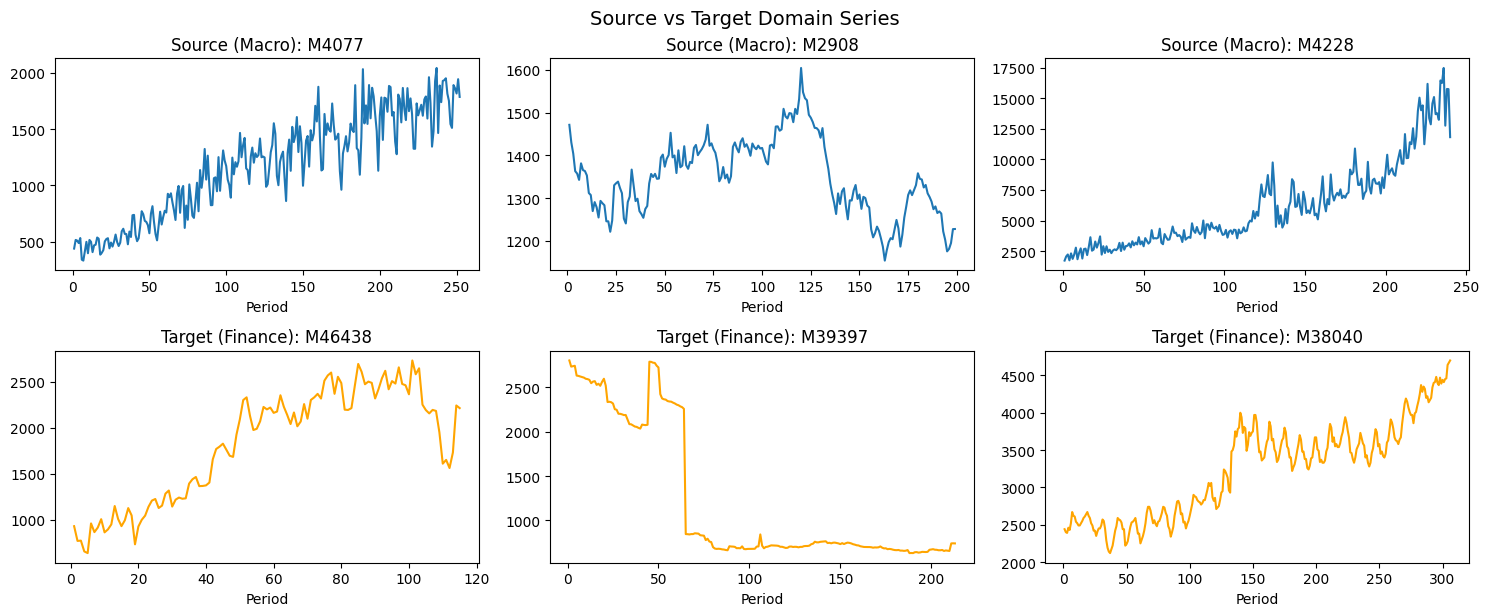

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6))

sample_source = source_ids[:3]
sample_target = target_ids[:3]

for ax, uid in zip(axes[0], sample_source):
    s = source_train[source_train['unique_id'] == uid]
    ax.plot(s['ds'], s['y'])
    ax.set_title(f'Source (Macro): {uid}')
    ax.set_xlabel('Period')

for ax, uid in zip(axes[1], sample_target):
    s = target_train[target_train['unique_id'] == uid]
    ax.plot(s['ds'], s['y'], color='orange')
    ax.set_title(f'Target (Finance): {uid}')
    ax.set_xlabel('Period')

plt.tight_layout()
plt.suptitle('Source vs Target Domain Series', y=1.02, fontsize=14)
plt.show()

## Fit MLForecast on Source Domain

We fit the model on Macro series using `PredictionIntervals` with:
- `method='weighted_conformal_error'` — stores lag features in the conformity score dataframe, enabling density-ratio estimation (DRE) for the `weighted_conformal` and `scale_aligned_weighted` transfer methods.
- `scale_estimator='mad'` — stores per-series scale estimates (MAD of first differences), enabling the `scale_aligned` and `scale_aligned_weighted` transfer methods.

Using this single fit configuration unlocks **all five** transfer methods.

In [6]:
mlf = MLForecast(
    models=lgb.LGBMRegressor(n_estimators=100, verbosity=-1, random_state=0),
    freq=1,
    lags=[1, 2, 3, 6, 12],
    lag_transforms={
        1: [ExpandingMean()],
        12: [RollingMean(window_size=6)],
    },
    target_transforms=[Differences([1])],
    num_threads=1,
)

mlf.fit(
    source_train,
    prediction_intervals=PredictionIntervals(
        n_windows=2,
        h=HORIZON,
        method='weighted_conformal_error',
        scale_estimator='mad',
    ),
)

MLForecast(models=[LGBMRegressor], freq=1, lag_features=['lag1', 'lag2', 'lag3', 'lag6', 'lag12', 'expanding_mean_lag1', 'rolling_mean_lag12_window_size6'], date_features=[], num_threads=1)

## Evaluate Transfer Methods

For each transfer method, we call `mlf.predict()` with:
- `new_df=target_train` — the target domain training history (Finance series)
- `level=[80, 90, 95]` — the requested coverage levels
- `transfer_conformal=method` — which transfer strategy to use

We then merge predictions with `target_test` and compute the **empirical coverage** at each level.

In [7]:
LEVELS = [80, 90, 95]
MODEL = 'LGBMRegressor'

transfer_methods = [
    'recalibrate',
    'scale_aligned',
    'error_scaled',
    'weighted_conformal',
    'scale_aligned_weighted',
]

coverage_results = {}

for method in transfer_methods:
    print(f"Running '{method}'...", end=' ', flush=True)
    preds = mlf.predict(
        h=HORIZON,
        level=LEVELS,
        new_df=target_train,
        transfer_conformal=method,
    )
    merged = target_test.merge(preds, on=['unique_id', 'ds'])
    cov = {}
    for lv in LEVELS:
        lo_col = f'{MODEL}-lo-{lv}'
        hi_col = f'{MODEL}-hi-{lv}'
        covered = (merged['y'] >= merged[lo_col]) & (merged['y'] <= merged[hi_col])
        cov[lv] = float(covered.mean())
    coverage_results[method] = cov
    print(f"done. Coverage: { {k: f'{v:.1%}' for k,v in cov.items()} }")

print("\nAll methods evaluated.")

Running 'recalibrate'... done. Coverage: {80: '65.1%', 90: '82.3%', 95: '90.8%'}
Running 'scale_aligned'... done. Coverage: {80: '73.5%', 90: '85.8%', 95: '91.9%'}
Running 'error_scaled'... done. Coverage: {80: '65.1%', 90: '81.5%', 95: '89.1%'}
Running 'weighted_conformal'... done. Coverage: {80: '78.9%', 90: '89.9%', 95: '95.4%'}
Running 'scale_aligned_weighted'... done. Coverage: {80: '77.2%', 90: '88.5%', 95: '93.8%'}

All methods evaluated.


## Results: Nominal vs Empirical Coverage

A well-calibrated method should have empirical coverage close to nominal. We show the results as a summary table and a bar chart.

In [8]:
# Build results dataframe
rows = []
for method, cov_dict in coverage_results.items():
    for lv, empirical in cov_dict.items():
        rows.append({
            'Method': method,
            'Nominal Level': f'{lv}%',
            'Nominal': lv / 100,
            'Empirical': empirical,
            'Gap': empirical - lv / 100,
        })

results_df = pd.DataFrame(rows)

# Pivot for display
pivot = results_df.pivot(index='Method', columns='Nominal Level', values='Empirical')
pivot = pivot[['80%', '90%', '95%']]
pivot.columns.name = 'Empirical Coverage @'
display_df = (pivot * 100).round(1).astype(str) + '%'

print("Empirical Coverage by Transfer Method (nominal levels: 80%, 90%, 95%)")
print("=" * 70)
print(display_df.to_string())

Empirical Coverage by Transfer Method (nominal levels: 80%, 90%, 95%)
Empirical Coverage @      80%    90%    95%
Method                                     
error_scaled            65.1%  81.5%  89.1%
recalibrate             65.1%  82.3%  90.8%
scale_aligned           73.5%  85.8%  91.9%
scale_aligned_weighted  77.2%  88.5%  93.8%
weighted_conformal      78.9%  89.9%  95.4%


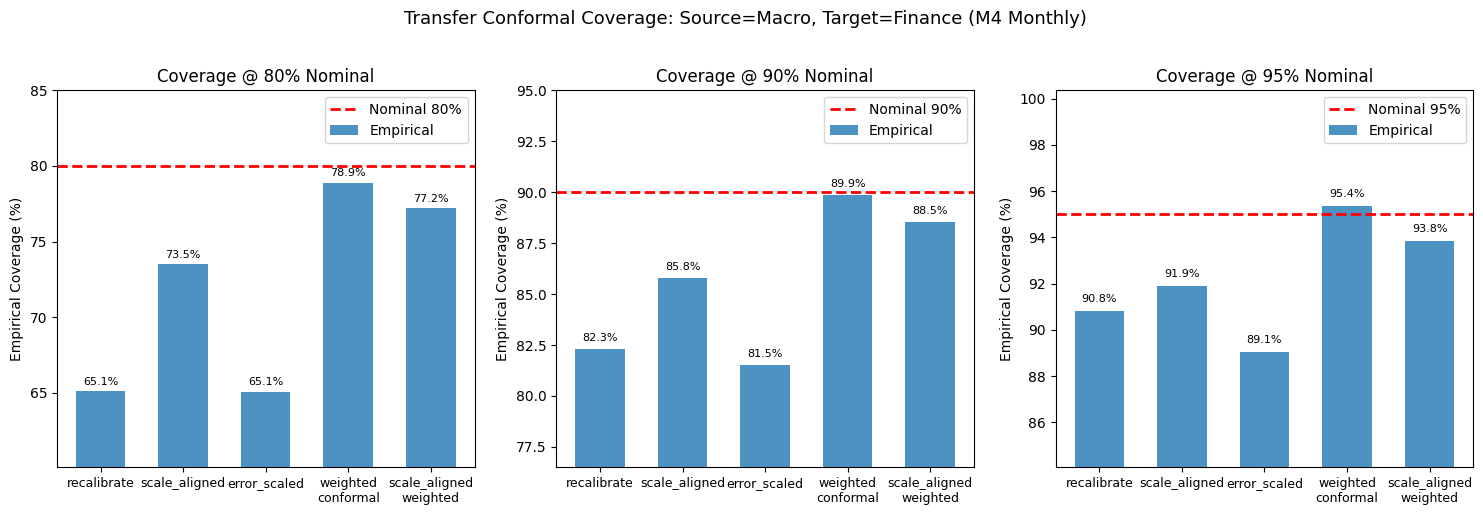

In [9]:
# Bar chart: empirical vs nominal coverage
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

method_labels = [
    'recalibrate',
    'scale_aligned',
    'error_scaled',
    'weighted\nconformal',
    'scale_aligned\nweighted',
]
x = np.arange(len(transfer_methods))

for ax, lv in zip(axes, LEVELS):
    empirical_vals = [coverage_results[m][lv] * 100 for m in transfer_methods]
    bars = ax.bar(x, empirical_vals, width=0.6, alpha=0.8, label='Empirical')
    ax.axhline(lv, color='red', linewidth=2, linestyle='--', label=f'Nominal {lv}%')
    ax.set_xticks(x)
    ax.set_xticklabels(method_labels, fontsize=9)
    ax.set_title(f'Coverage @ {lv}% Nominal', fontsize=12)
    ax.set_ylabel('Empirical Coverage (%)')
    ax.legend()
    # Add value labels on bars
    for bar, val in zip(bars, empirical_vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=8
        )
    y_min = min(min(empirical_vals), lv) - 5
    y_max = max(max(empirical_vals), lv) + 5
    ax.set_ylim(y_min, y_max)

plt.suptitle(
    'Transfer Conformal Coverage: Source=Macro, Target=Finance (M4 Monthly)',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

## Coverage Gap Analysis

In [10]:
# Signed gap: positive = over-coverage, negative = under-coverage
gap_pivot = results_df.pivot(index='Method', columns='Nominal Level', values='Gap')[['80%', '90%', '95%']]
gap_display = (gap_pivot * 100).round(2)

print("Coverage gap (Empirical − Nominal) in percentage points:")
print("  Positive = over-coverage (wider intervals than needed)")
print("  Negative = under-coverage (intervals too narrow)")
print()
print(gap_display.to_string())

# Best method: smallest mean absolute gap across all levels
mean_abs_gap = gap_pivot.abs().mean(axis=1).sort_values()
print("\nMethods ranked by mean |gap| across all levels:")
for method, gap in mean_abs_gap.items():
    print(f"  {method}: {gap*100:.2f} pp")

Coverage gap (Empirical − Nominal) in percentage points:
  Positive = over-coverage (wider intervals than needed)
  Negative = under-coverage (intervals too narrow)

Nominal Level             80%   90%   95%
Method                                   
error_scaled           -14.92 -8.50 -5.94
recalibrate            -14.89 -7.69 -4.17
scale_aligned           -6.50 -4.22 -3.08
scale_aligned_weighted  -2.81 -1.47 -1.17
weighted_conformal      -1.11 -0.14  0.36

Methods ranked by mean |gap| across all levels:
  weighted_conformal: 0.54 pp
  scale_aligned_weighted: 1.81 pp
  scale_aligned: 4.60 pp
  recalibrate: 8.92 pp
  error_scaled: 9.79 pp


## Interval Width Analysis

Beyond coverage, we also care about interval sharpness. Narrower intervals (lower width) are better, as long as coverage is maintained.

In [11]:
width_results = {}

for method in transfer_methods:
    preds = mlf.predict(
        h=HORIZON,
        level=LEVELS,
        new_df=target_train,
        transfer_conformal=method,
    )
    widths = {}
    for lv in LEVELS:
        lo_col = f'{MODEL}-lo-{lv}'
        hi_col = f'{MODEL}-hi-{lv}'
        width = (preds[hi_col] - preds[lo_col]).mean()
        widths[lv] = float(width)
    width_results[method] = widths

width_df = pd.DataFrame(width_results).T
width_df.columns = [f'{lv}%' for lv in LEVELS]
print("Mean interval width by method and level:")
print(width_df.round(2).to_string())

Mean interval width by method and level:
                            80%      90%       95%
recalibrate             1770.87  3528.82   5791.20
scale_aligned           3718.26  6274.33  10585.71
error_scaled            1701.93  3245.48   4995.96
weighted_conformal      2109.23  4161.83   6781.60
scale_aligned_weighted  4214.72  7494.83  13857.89


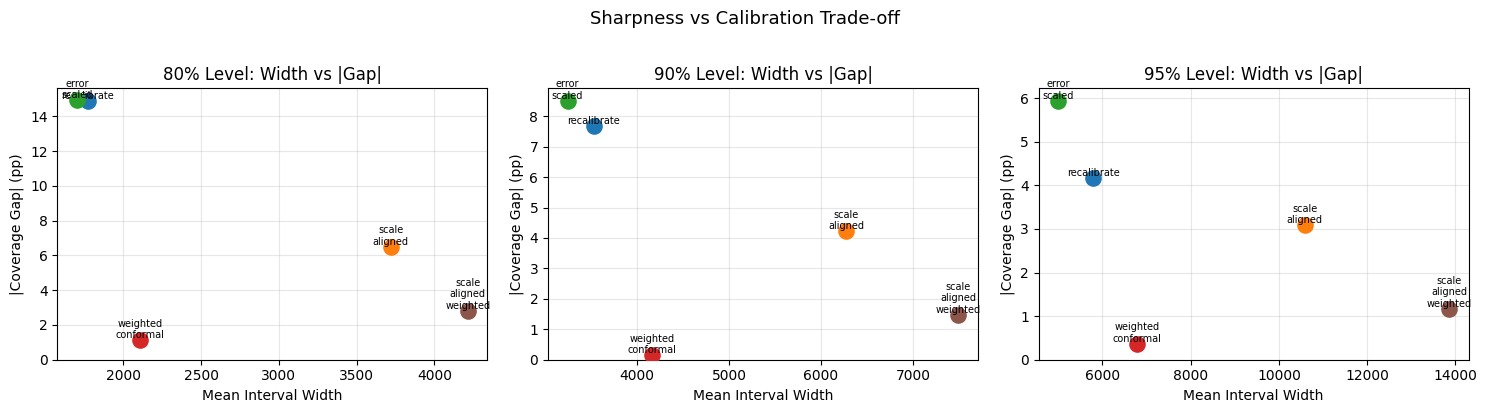

In [12]:
# Scatter plot: width vs coverage gap (ideal: small gap, narrow width)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors = plt.cm.tab10(np.linspace(0, 0.5, len(transfer_methods)))

for ax, lv in zip(axes, LEVELS):
    for i, method in enumerate(transfer_methods):
        gap = abs(coverage_results[method][lv] - lv / 100) * 100
        width = width_results[method][lv]
        ax.scatter(width, gap, color=colors[i], s=120, label=method, zorder=3)
        ax.annotate(
            method.replace('_', '\n'),
            (width, gap), fontsize=7, ha='center', va='bottom'
        )
    ax.set_xlabel('Mean Interval Width')
    ax.set_ylabel('|Coverage Gap| (pp)')
    ax.set_title(f'{lv}% Level: Width vs |Gap|')
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)

plt.suptitle('Sharpness vs Calibration Trade-off', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Visual Inspection: Interval Examples

Let's visually inspect the intervals produced by each method for a few target-domain series.

In [13]:
PLOT_LEVEL = 90
EXAMPLE_IDS = target_ids[:4].tolist()

# Collect predictions for all methods
all_preds = {}
for method in transfer_methods:
    preds = mlf.predict(
        h=HORIZON,
        level=[PLOT_LEVEL],
        new_df=target_train[target_train['unique_id'].isin(EXAMPLE_IDS)],
        transfer_conformal=method,
    )
    all_preds[method] = preds

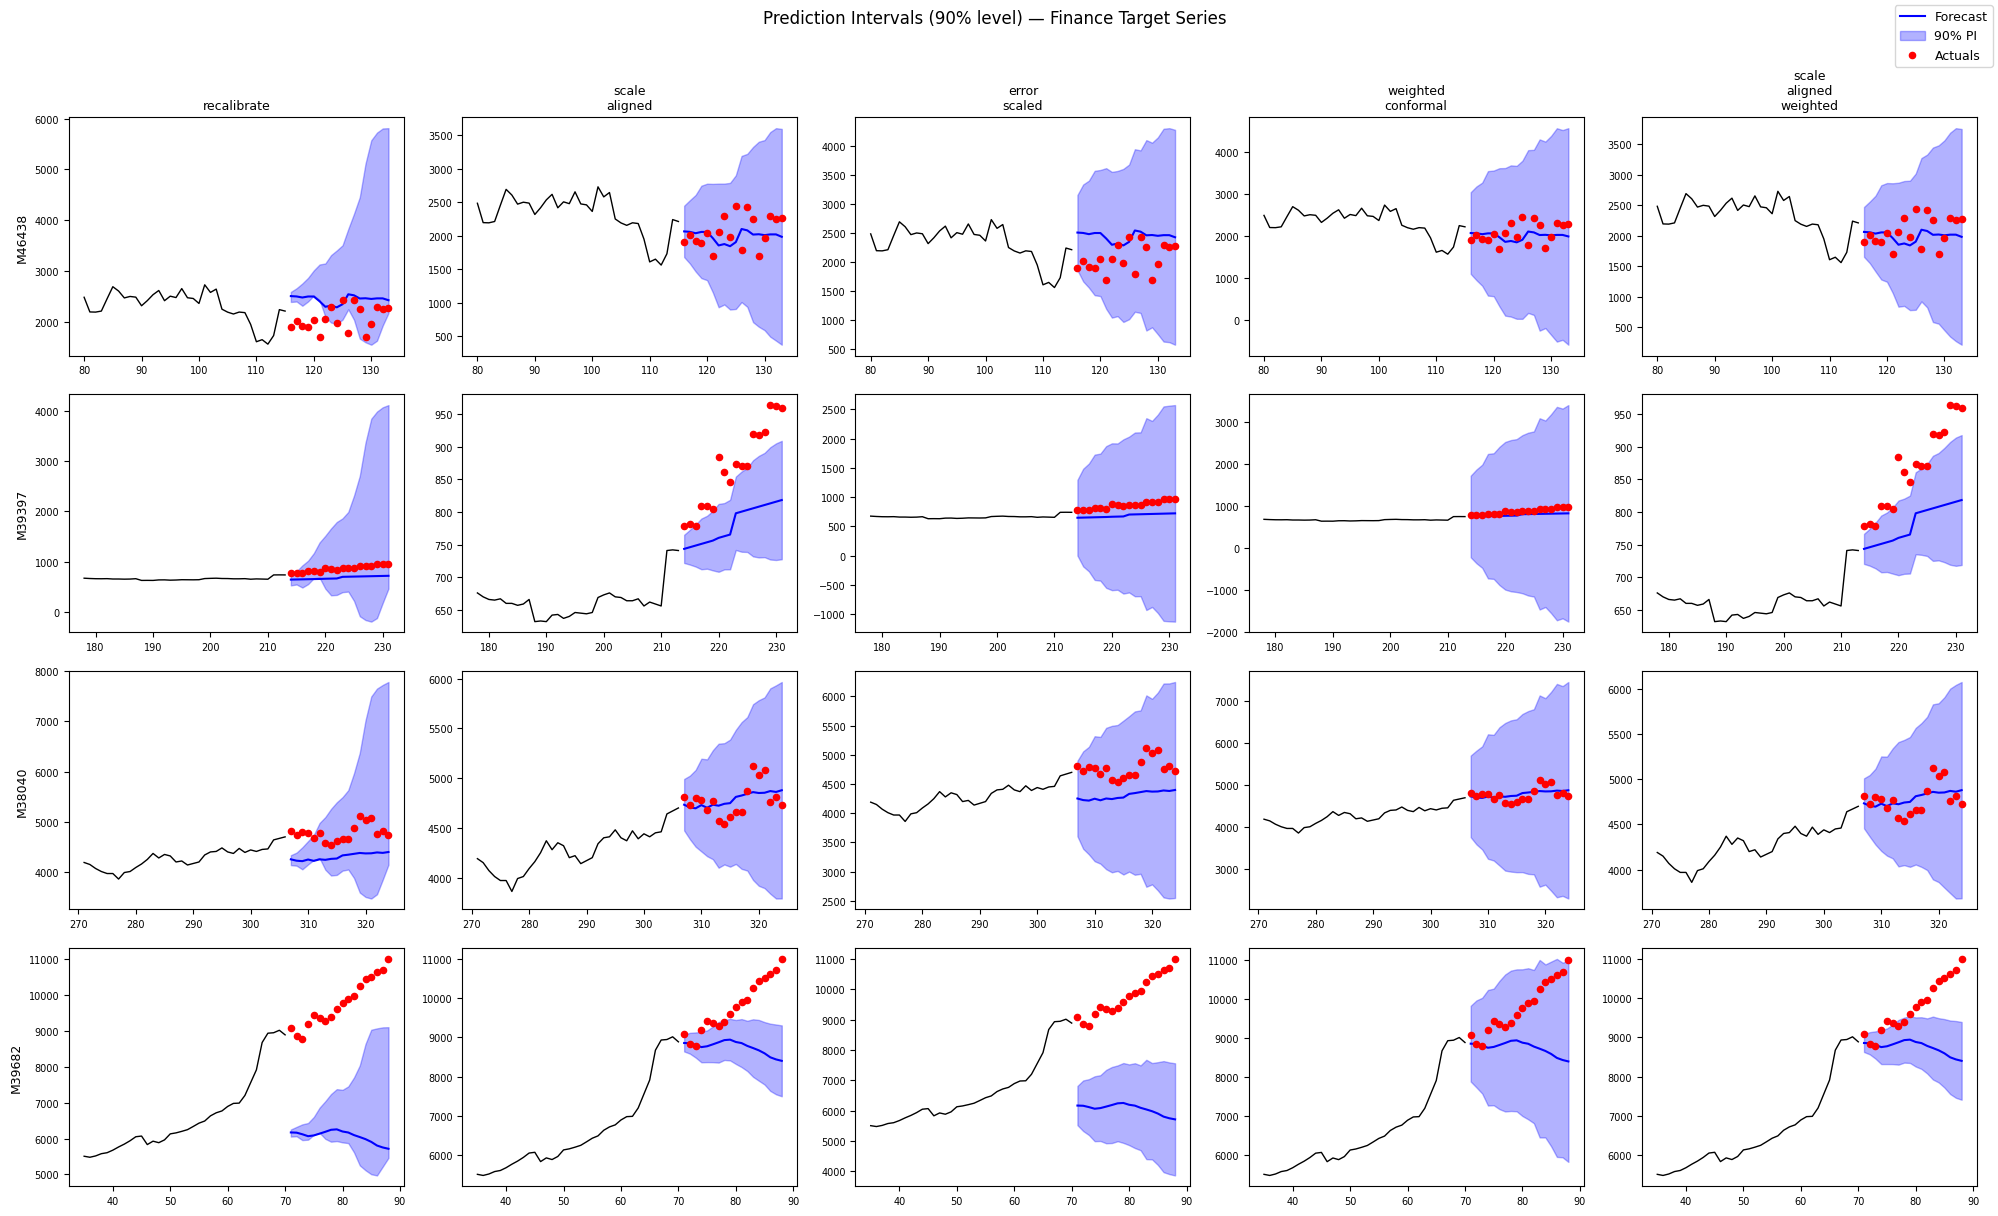

In [14]:
fig, axes = plt.subplots(
    len(EXAMPLE_IDS), len(transfer_methods),
    figsize=(4 * len(transfer_methods), 3 * len(EXAMPLE_IDS)),
    sharex='row'
)

lo_col = f'{MODEL}-lo-{PLOT_LEVEL}'
hi_col = f'{MODEL}-hi-{PLOT_LEVEL}'

for row, uid in enumerate(EXAMPLE_IDS):
    hist = target_train[target_train['unique_id'] == uid].tail(36)
    test = target_test[target_test['unique_id'] == uid]
    for col, method in enumerate(transfer_methods):
        ax = axes[row][col]
        pred = all_preds[method][all_preds[method]['unique_id'] == uid]
        ax.plot(hist['ds'], hist['y'], color='black', linewidth=1)
        ax.plot(pred['ds'], pred[MODEL], color='blue', linewidth=1.5, label='Forecast')
        ax.fill_between(
            pred['ds'], pred[lo_col], pred[hi_col],
            alpha=0.3, color='blue', label=f'{PLOT_LEVEL}% PI'
        )
        ax.scatter(test['ds'], test['y'], color='red', s=20, zorder=5, label='Actuals')
        if row == 0:
            ax.set_title(method.replace('_', '\n'), fontsize=9)
        if col == 0:
            ax.set_ylabel(f'{uid}', fontsize=9)
        ax.tick_params(labelsize=7)

# Single legend at top
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=9)

plt.suptitle(
    f'Prediction Intervals ({PLOT_LEVEL}% level) — Finance Target Series',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

## Summary

The table and charts above show how each transfer method calibrates prediction intervals when moving from a Macro source domain to a Finance target domain in M4 Monthly data.

**Key takeaways:**

- `recalibrate` runs cross-validation on the target data — it tends to be the most directly calibrated but requires running CV (computationally equivalent to retraining).
- `scale_aligned` uses the scale of the *y* signal (MAD of differences) to align source residuals — zero-shot, no CV needed.
- `error_scaled` runs CV on the target data to estimate prediction error magnitude — a middle ground between full recalibration and scale alignment.
- `weighted_conformal` uses density-ratio estimation to reweight source conformity scores — handles covariate shift without needing target labels during calibration.
- `scale_aligned_weighted` combines scale alignment with DRE weighting — the most sophisticated zero-shot method.

The right method to use depends on your constraints:
- If you can run CV on the target: `recalibrate` or `error_scaled`
- If you need zero-shot transfer: `scale_aligned` or `scale_aligned_weighted`
- If covariate shift is the main concern: `weighted_conformal` or `scale_aligned_weighted`